In [1]:
import cmdstanpy
import matplotlib.pyplot as plt
import numpy as np
import pyreadr
from cmdstanpy import CmdStanModel
cmdstanpy.install_cmdstan();

CmdStan install directory: /Users/cwf25/.cmdstan
CmdStan version 2.38.0 already installed
Test model compilation


In [2]:
seed = 739485
rng = np.random.default_rng(seed)

In [3]:
df = pyreadr.read_r('data/data.Rda')[None]
df.head().style.hide(axis='index')

y,time
0.795570,0.000000
0.174560,0.500000
0.774322,1.000000
3.083851,1.500000
2.163227,2.000000


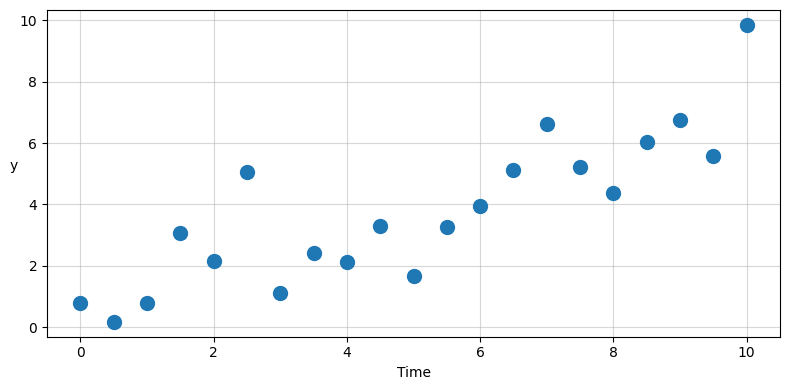

In [4]:
t = df['time']
fig, ax = plt.subplots(figsize=(8, 4))
ax.grid(alpha=.5)
ax.scatter(t, df['y'], s=100, zorder=2)
ax.set_xlabel('Time')
ax.set_ylabel(ylabel='y', rotation=0.)
fig.tight_layout()

In [5]:
# Only want to solve the ODE at unique time points to reduce runtime
time_pts = np.sort(t.unique())

# Dictionary of data corresponding to the model definition in 'cmdstanpy.stan'
stan_data = {
    'N': len(df),
    'T': len(time_pts),
    'y': df['y'].to_numpy(),
    't': time_pts,
    't_idx': [np.where(time_pts == t)[0].item() + 1 for t in df['time']],
    'include_likelihood': True
}

In [6]:
model = CmdStanModel(stan_file='model.stan')
fit = model.sample(stan_data, chains=4, seed=seed)

15:44:32 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

15:44:33 - cmdstanpy - INFO - CmdStan done processing.
15:44:33 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Location parameter[2] is nan, but must be finite! (in 'model.stan', line 41, column 8 to column 35)
	Exception: normal_lpdf: Location parameter[2] is nan, but must be finite! (in 'model.stan', line 41, column 8 to column 35)
	Exception: normal_lpdf: Location parameter[2] is nan, but must be finite! (in 'model.stan', line 41, column 8 to column 35)
	Exception: normal_lpdf: Location parameter[2] is nan, but must be finite! (in 'model.stan', line 41, column 8 to column 35)
	Exception: normal_lpdf: Location parameter[2] is nan, but must be finite! (in 'model.stan', line 41, column 8 to column 35)
	Exception: normal_lpdf: Location parameter[2] is nan, but must be finite! (in 'model.stan', line 41, column 8 to column 35)
	Exception: normal_lpdf: Location parameter[2] is nan, but must be finite! (in 'model.stan', line 41, column 8 to column 35)
	Exce

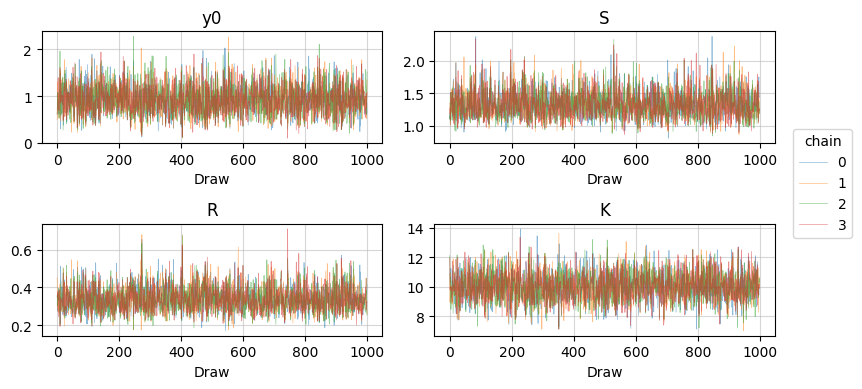

In [7]:
params = ('y0', 'S', 'R', 'K')
n_draws = len(draws := fit.draws_pd())
n_chains = len(draws['chain__'].unique())
fig, axes = plt.subplots(round(len(params)/2), 2, figsize=(8, 4))

for ax, param in zip(axes.flatten(), params):
    ax.grid(alpha=.5)
    param_draws = draws[param].to_numpy().reshape(n_draws//n_chains, n_chains)
    lines = ax.plot(param_draws, alpha=.5, linewidth=.5)
    ax.set(title=param, xlabel='Draw')

fig.legend(lines, np.arange(n_chains), title='chain', bbox_to_anchor=(1.08, .68))
fig.tight_layout()

In [8]:
fit.summary().head()[1:]

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
y0,0.925203,0.007033,0.316794,0.321314,0.444505,0.905739,1.483110,1954.86,1811.00,2299.84,1.00209
S,1.332040,0.004646,0.211573,0.202413,1.032940,1.309270,1.714240,2254.30,1824.27,2652.11,1.00103
R,0.339689,0.001639,0.066649,0.063729,0.243067,0.332167,0.457649,1817.18,1907.78,2137.86,1.00231
K,10.039900,0.019788,0.980146,0.998423,8.468880,10.034700,11.688800,2467.91,2285.52,2903.42,1.00147


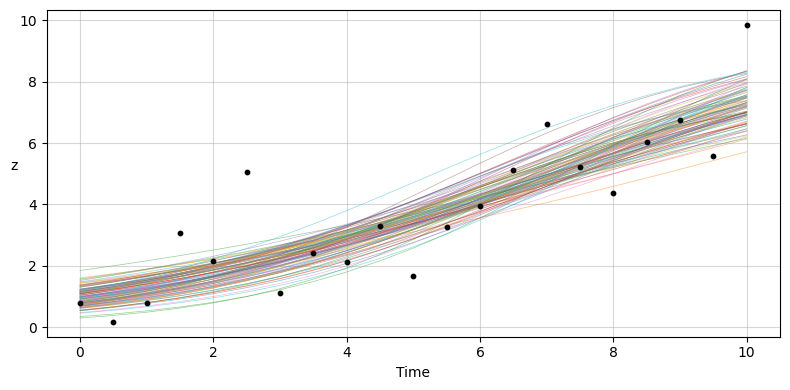

In [9]:
z_keys = [f'z_rep[{i + 1}]' for i in range(stan_data['N'])]
sample_idx = rng.integers(0, n_draws, 100)
z = draws[z_keys].loc[sample_idx].T.to_numpy()
fig, ax = plt.subplots(figsize=(8, 4))
ax.grid(alpha=.5)
ax.plot(stan_data['t'], z, alpha=.5, linewidth=.5)
ax.scatter(t, df['y'], s=10, c='black', zorder=2)
ax.set_xlabel('Time')
ax.set_ylabel('z', rotation=0.)
fig.tight_layout()

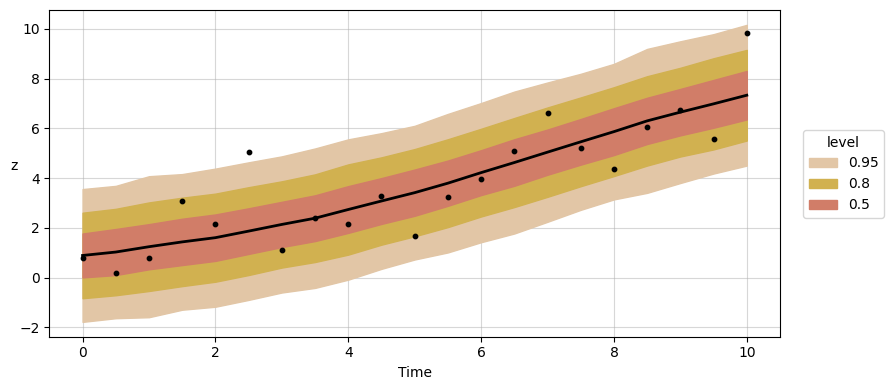

In [10]:
y_keys = [f'y_rep[{i + 1}]' for i in range(stan_data['N'])]
y = (y_draws := draws[y_keys].T.to_numpy()).mean(-1)
d = np.sort(np.sqrt(np.square((y_draws - y[:, None]))), -1)
levels, colors, fills = (.95, .8, .5), ('#e2c6a6', '#d1b150', '#d17d68'), []
fig, ax = plt.subplots(figsize=(8, 4))
ax.grid(alpha=.5)

for level, color in zip(levels, colors):
    h = d[:, round(level*d.shape[1])]
    fills.append(ax.fill_between(stan_data['t'], y - h, y + h, color=color, zorder=2))

ax.plot(stan_data['t'], y, linewidth=2., color='black')
ax.scatter(t, df['y'], s=10, c='black', zorder=2)
ax.set_xlabel('Time')
ax.set_ylabel('z', rotation=0.)
fig.legend(fills, levels, title='level', bbox_to_anchor=(1.12, .68))
fig.tight_layout()

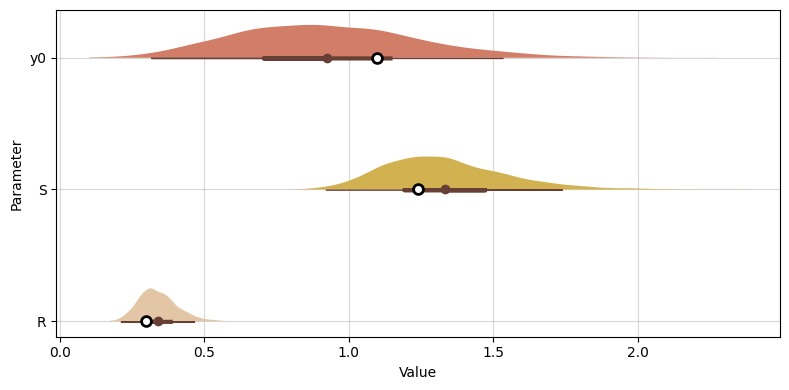

In [12]:
true_params = pyreadr.read_r('data/params.Rda')['params']
param_keys = [param for param in params if param in true_params][::-1]
fig, ax = plt.subplots(figsize=(8, 4))
ax.grid(alpha=.5)

for (i, param), color in zip(enumerate(param_keys), colors):
    param_mean, param_draws = fit.summary()['Mean'][param], draws[param]
    violin = ax.violinplot(param_draws, [i], orientation='horizontal', showextrema=False, side='high')
    violin['bodies'][0].set_facecolor(color)
    violin['bodies'][0].set_alpha(1.)
    violin['bodies'][0].set_zorder(2)
    d = np.argsort(np.sqrt(np.square((param_draws - param_mean))))
    level_50, level_95 = param_draws[d[:round(.5*len(draws))]], param_draws[d[:round(.95*len(draws))]]
    ax.plot(level_50, (i - .005)*np.ones_like(level_50), linewidth=3., color='#683f34')
    ax.plot(level_95, (i - .005)*np.ones_like(level_95), linewidth=1., color='#683f34')
    ax.scatter(param_mean, i, zorder=2, color='#683f34')
    param_value = true_params[param].item()
    ax.scatter(param_value, i, s=50, linewidths=2., facecolors='white', edgecolors='black', zorder=2)

ax.set_yticks(range(len(param_keys)), param_keys)
ax.set_xlabel('Value')
ax.set_ylabel('Parameter')
fig.tight_layout()